In [102]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import rdkit
from rdkit import Chem

print(rdkit.__version__)

2025.09.1


In [98]:
root = 'data/generated_6/'

In [99]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

def visualize_point_clouds(x_file, pos_file, batch_file):
    """
    Visualizes 3D point clouds stored in PyTorch .pt files with categorical colors for atom types
    and varying saturation for hybridization states.

    Args:
        x_file (str): Path to the .pt file containing point types (integers).
        pos_file (str): Path to the .pt file containing point positions (3D coordinates).
        batch_file (str): Path to the .pt file containing batch assignments (integers).
    """
    # Mapping of point types to atom and hybridization states
    type_mapping = {
        1: "(1, -1): H (unknown)",
        2: "(1, 0): H (s)",
        3: "(6, -1): C (unknown)",
        4: "(6, 1): C (sp)",
        5: "(6, 2): C (sp2)",
        6: "(6, 3): C (sp3)",
        7: "(7, -1): N (unknown)",
        8: "(7, 1): N (sp)",
        9: "(7, 2): N (sp2)",
        10: "(7, 3): N (sp3)",
        11: "(8, -1): O (unknown)",
        12: "(8, 2): O (sp2)",
        13: "(8, 3): O (sp3)",
        14: "(9, -1): F (unknown)",
        15: "(9, 3): F (sp3)"
    }

    # Define categorical colors for each atom type
    base_colors = {
        1: "blue",   # Hydrogen (H)
        6: "gray",   # Carbon (C)
        7: "green",  # Nitrogen (N)
        8: "red",    # Oxygen (O)
        9: "purple"  # Fluorine (F)
    }

    # Function to adjust color saturation for hybridization states
    def adjust_saturation(color, hybridization):
        """
        Adjusts the saturation of a base color based on the hybridization state.
        Args:
            color (str): Base color name or hex code.
            hybridization (int): Hybridization state (-1, 0, 1, 2, 3).
        Returns:
            str: Adjusted color in hex format.
        """
        base_color = mcolors.to_rgb(color)
        if hybridization == -1:  # Unknown
            factor = 0.3  # Low saturation
        elif hybridization == 0:  # s
            factor = 0.5
        elif hybridization == 1:  # sp
            factor = 0.7
        elif hybridization == 2:  # sp2
            factor = 0.85
        elif hybridization == 3:  # sp3
            factor = 1.0  # Full saturation
        adjusted_color = tuple(factor * c for c in base_color)
        return mcolors.to_hex(adjusted_color)

    # Load the data from .pt files
    x = torch.load(x_file).detach().cpu()  # Point types (integers)
    pos = torch.load(pos_file).detach().cpu()  # Point positions (3D coordinates)
    batch = torch.load(batch_file).detach().cpu()  # Batch assignments (integers)

    # Ensure the data is in the correct format
    assert pos.shape[1] == 3, "Positions should have 3 columns (x, y, z)."
    assert len(x) == len(pos) == len(batch), "Mismatch in data lengths."

    # Get the unique batch indices (graphs)
    unique_batches = torch.unique(batch)

    # Create a 3D plot for each graph
    for b in unique_batches:
        # Filter points belonging to the current batch
        mask = batch == b
        points = pos[mask]
        types = x[mask]

        # Map point types to colors
        colors = []
        for t in types:
            for key, value in type_mapping.items():
                if t.item() == key:
                    atom_number, hybridization = eval(value.split(":")[0])  # Extract (atomic_number, hybridization)
                    base_color = base_colors[atom_number]
                    colors.append(adjust_saturation(base_color, hybridization))
                    break

        # Create a 3D scatter plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=20)

        # Add legend for atom types and hybridization states
        legend_elements = []
        for key, value in type_mapping.items():
            atom_number, hybridization = eval(value.split(":")[0])  # Extract (atomic_number, hybridization)
            base_color = base_colors[atom_number]
            color = adjust_saturation(base_color, hybridization)
            legend_elements.append(Line2D([0], [0], marker='o', color='w', label=f'{value}', 
                                          markerfacecolor=color, markersize=8))
        ax.legend(handles=legend_elements, loc='upper right', title="Atom (Hybridization)")

        # Add labels and title
        ax.set_title(f'3D Point Cloud for Graph {b.item()}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        # Show the plot
        plt.show()

Error processing molecule 0: Valence of atom 13 is 5, which is larger than the allowed maximum, 4
Error processing molecule 1: Final molecular charge (0) does not match input (-1); could not find valid bond ordering
Error processing molecule 3: Final molecular charge (0) does not match input (-1); could not find valid bond ordering
Error processing molecule 8: Valence of atom 19 is 5, which is larger than the allowed maximum, 4
Error processing molecule 11: Valence of atom 11 is 5, which is larger than the allowed maximum, 4
Error processing molecule 12: Valence of atom 3 is 5, which is larger than the allowed maximum, 4
Error processing molecule 18: Valence of atom 9 is 5, which is larger than the allowed maximum, 4
Error processing molecule 19: Final molecular charge (0) does not match input (-1); could not find valid bond ordering
Error processing molecule 20: Final molecular charge (0) does not match input (-1); could not find valid bond ordering
Error processing molecule 21: Final

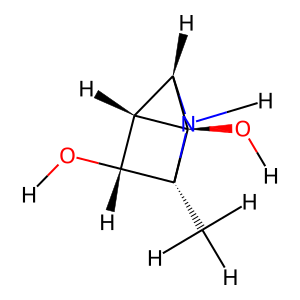

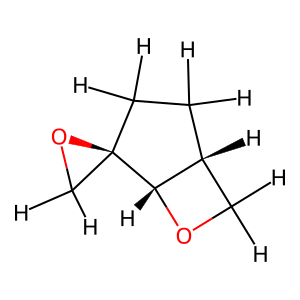

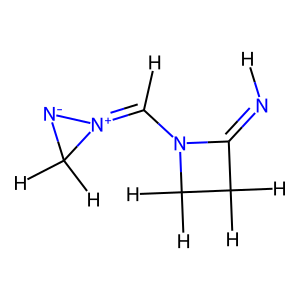

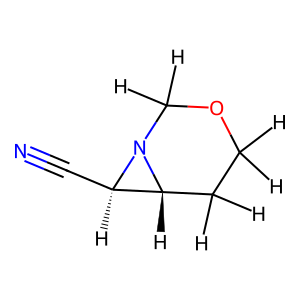

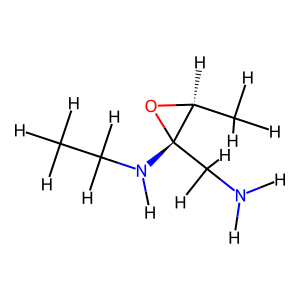

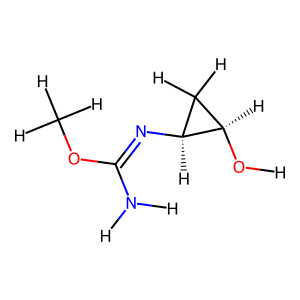

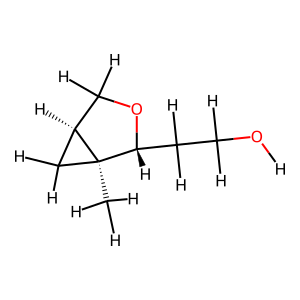

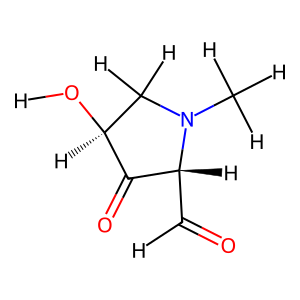

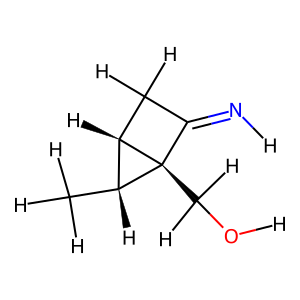

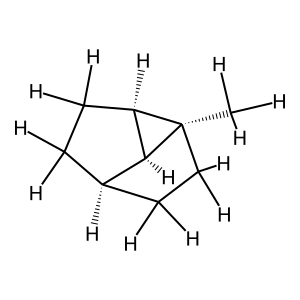

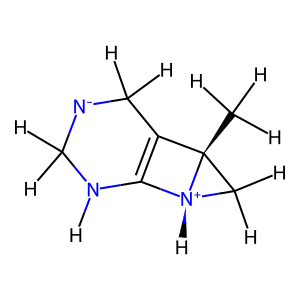

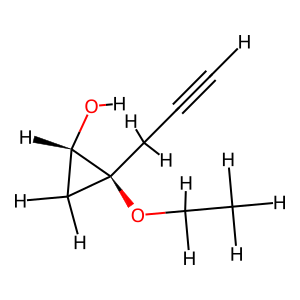

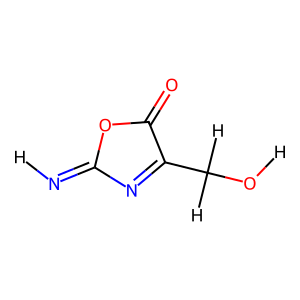

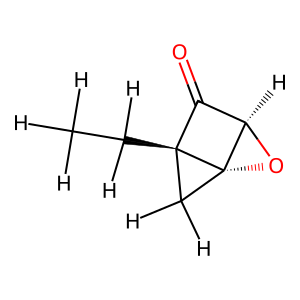

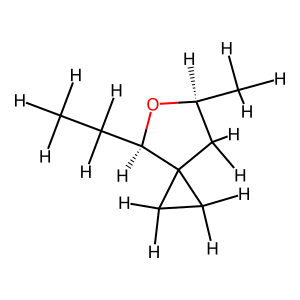

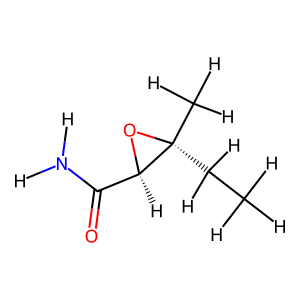

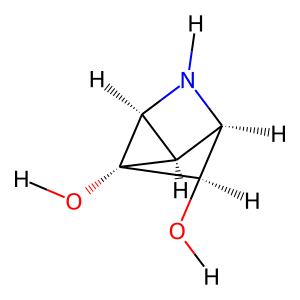

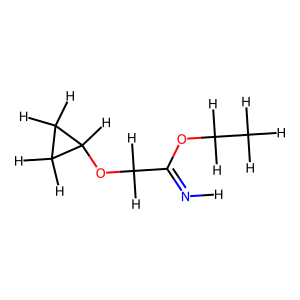

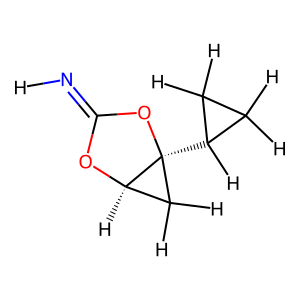

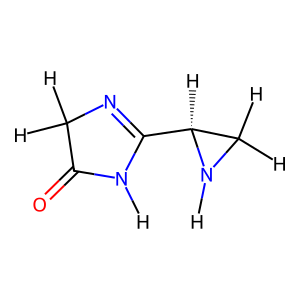

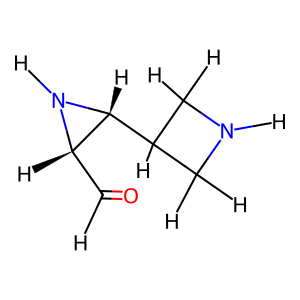

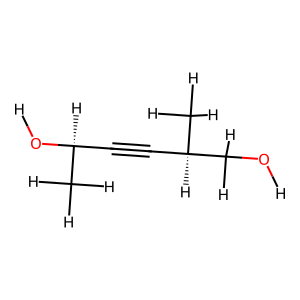

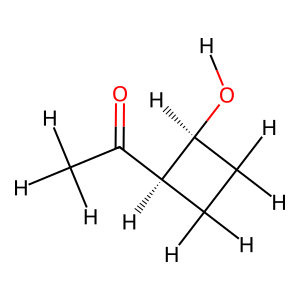

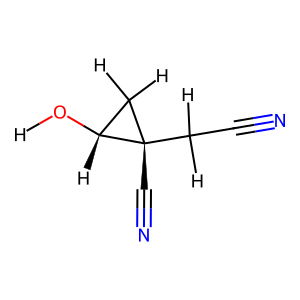

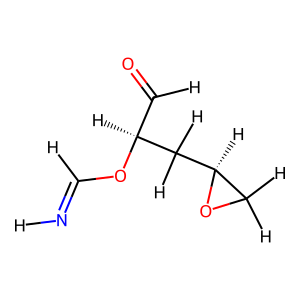

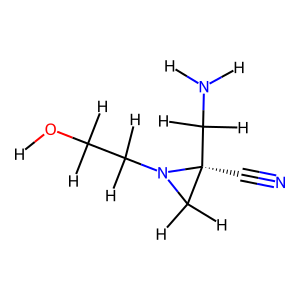

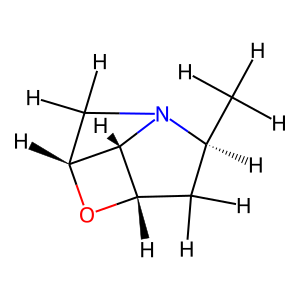

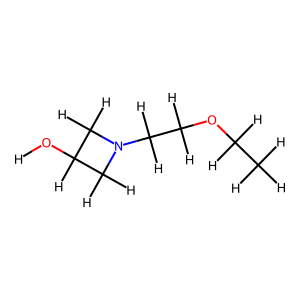

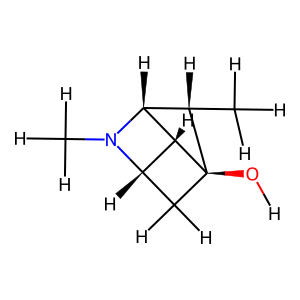

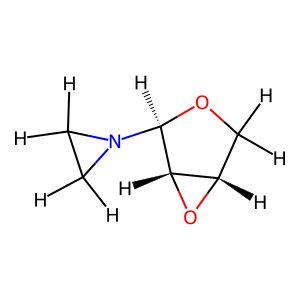

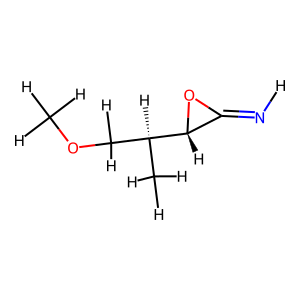

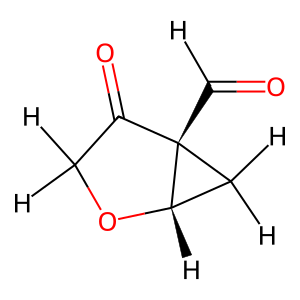

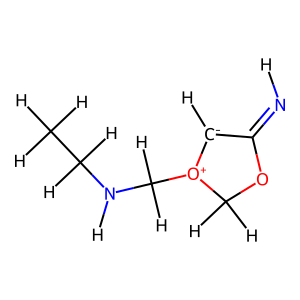

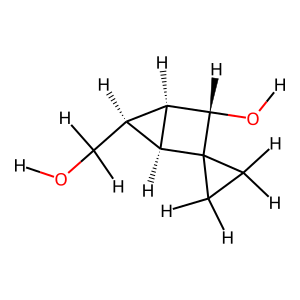

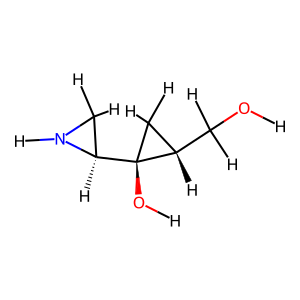

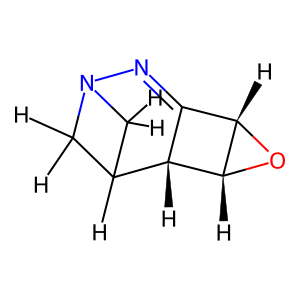

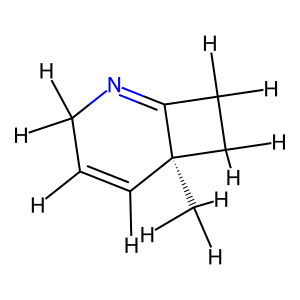

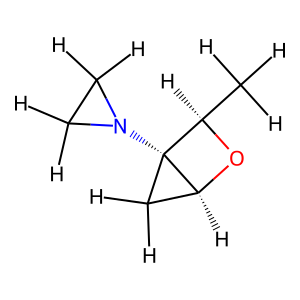

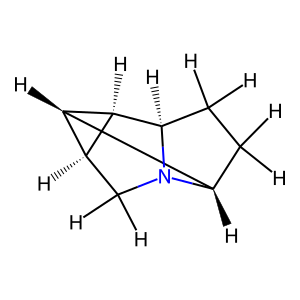

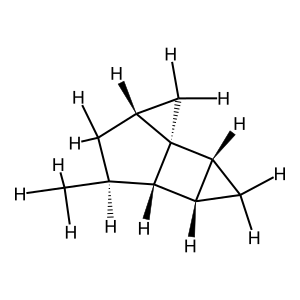

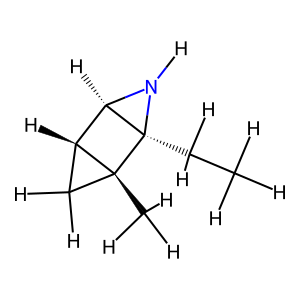

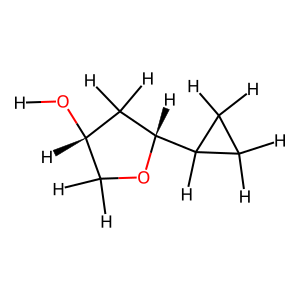

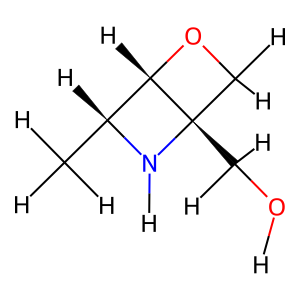

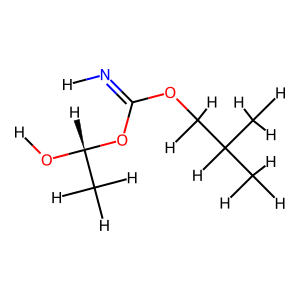

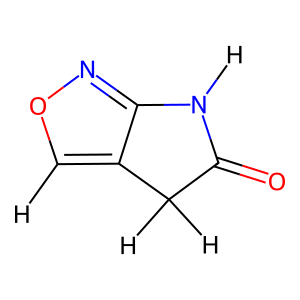

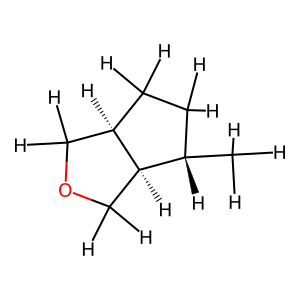

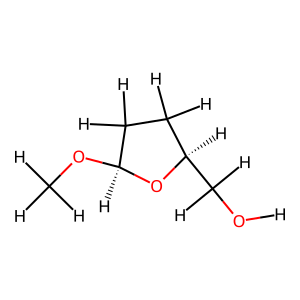

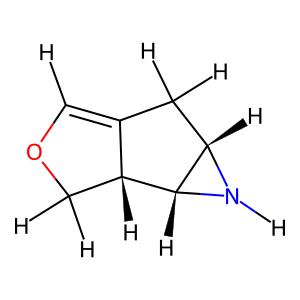

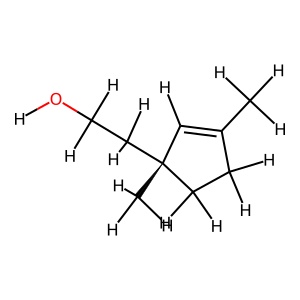

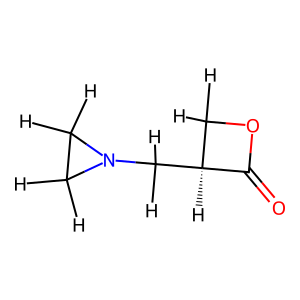

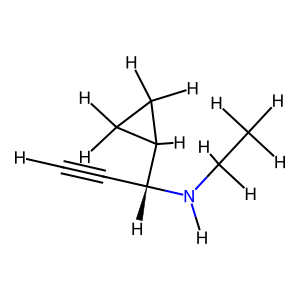

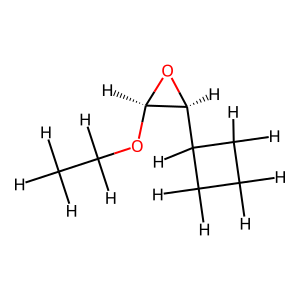

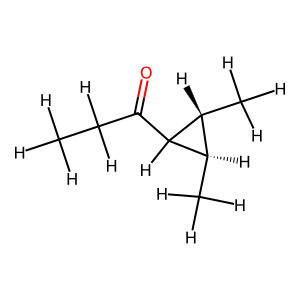

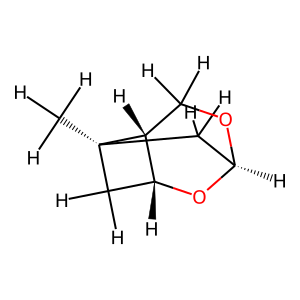

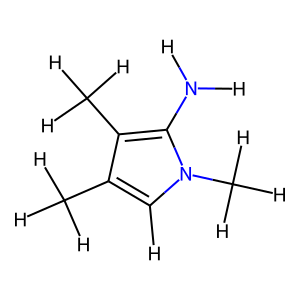

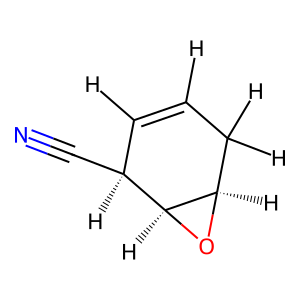

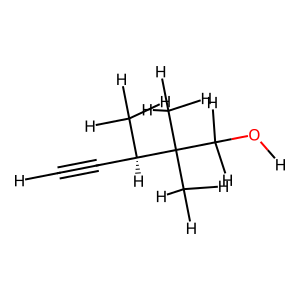

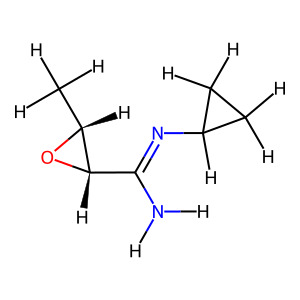

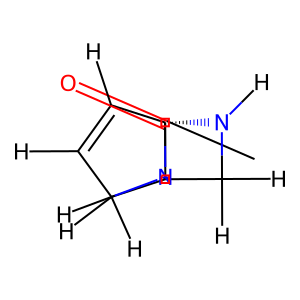

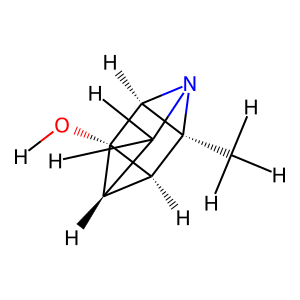

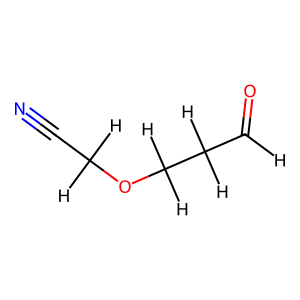

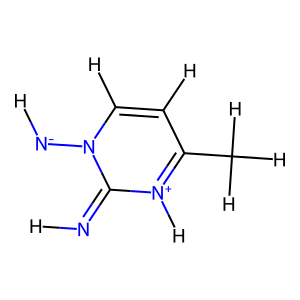

In [100]:
# Map atom types to chemical elements
atom_type_to_element = {
    1: 'H',  # Hydrogen
    2: 'H',  # Hydrogen
    3: 'C',  # Carbon
    4: 'C',  # Carbon
    5: 'C',  # Carbon
    6: 'C',  # Carbon
    7: 'N',  # Nitrogen
    8: 'N',  # Nitrogen
    9: 'N',  # Nitrogen
    10: 'N',  # Nitrogen
    11: 'O',  # Oxygen
    12: 'O',  # Oxygen
    13: 'O',  # Oxygen
    14: 'F',  # Fluorine
    15: 'F',  # Fluorine
}

def create_xyz_block(x, pos):
    xyz_lines = []
    num_atoms = x.size(0)
    xyz_lines.append(f"{num_atoms}")
    xyz_lines.append("")

    for i in range(num_atoms):
        atom_type = x[i].item()
        element = atom_type_to_element.get(atom_type, 'X')
        x_coord, y_coord, z_coord = pos[i].tolist()
        xyz_lines.append(f"{element}\t{x_coord:.4f}\t{y_coord:.4f}\t{z_coord:.4f}")

    return "\n".join(xyz_lines)


# Load the data
x = torch.load(f'{root}x_100.pt').detach().cpu()  # Atom types (integers)
pos = torch.load(f'{root}pos_100.pt').detach().cpu()  # 3D positions (floats)
batch = torch.load(f'{root}batch_source_100.pt').detach().cpu()  # Batch assignments (integers)

# Generate RDKit Mol objects
mols = []
unique_batches = torch.unique(batch)
n_valid = 0
for b in unique_batches:
    mask = batch == b
    x_b = x[mask]
    pos_b = pos[mask]
    try:
        xyz_block = create_xyz_block(x_b, pos_b)
        mol = Chem.MolFromXYZBlock(xyz_block)
        Chem.rdDetermineBonds.DetermineBonds(mol, charge=0)
        mols.append(mol)
        n_valid += 1
    except Exception as e:
        print(f"Error processing molecule {b}: {e}")

print(f"Number of valid molecules: {n_valid} out of {len(unique_batches)}")

for mol in mols:
    Chem.rdDepictor.Compute2DCoords(mol)
    img = Chem.Draw.MolToImage(mol)
    display(img)

In [101]:
from rdkit.Chem import AllChem
import py3Dmol

def visualize_molecule_3d(mol, width=400, height=400):
    # Generate 3D coordinates if not already present
    if not mol.GetNumConformers():
        AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        AllChem.UFFOptimizeMolecule(mol)
    
    # Convert RDKit molecule to a 3D SDF string
    sdf_block = Chem.MolToMolBlock(mol)
    
    # Create a py3Dmol view
    view = py3Dmol.view(width=width, height=height)
    view.addModel(sdf_block, "sdf")
    # Set the visualization style to "stick and balls"
    view.setStyle({
        "stick": {},
        "sphere": {"scale": 0.3}
    })
    view.zoomTo()
    return view.show()

visualize_molecule_3d(mols[3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.